# Air Quality Forecasting

## AI-ML Recruitment Task – Second Year

### Objective
The objective of this project is to analyse historical air-quality measurements
and build a machine-learning model to predict a future air-quality measurement.

### Project Sections
1. Data Understanding and Preprocessing
2. Exploratory Data Analysis
3. Feature Engineering
4. Prediction
5. Model Analysis
6. Insights and Conclusion

In [6]:
import pandas as pd
import numpy as np
import io
import requests
import zipfile

# ==============================================================================
# PART A: DATA UNDERSTANDING & PREPROCESSING

print("--- PART A: Loading & Preprocessing Data ---")

# 1. Download and extract 'AirQualityUCI.csv' specifically from the ZIP archive
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip"
response = requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open('AirQualityUCI.csv') as f:
        df_raw = pd.read_csv(f, sep=';', decimal=',')

# Drop trailing empty rows/columns generated by double semicolons
df = df_raw.dropna(how='all', axis=1).dropna(how='all', axis=0).copy()

# Parse Datetime
df['Time'] = df['Time'].astype(str).str.replace('.', ':', regex=False)
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S', errors='coerce')

# Drop unparseable datetime rows, sort chronologically, drop original date/time strings
df = df.dropna(subset=['Datetime']).sort_values('Datetime').reset_index(drop=True)
df = df.drop(columns=['Date', 'Time'])

# Drop NMHC(GT) as it typically contains >90% missing values in this dataset
if 'NMHC(GT)' in df.columns:
    df = df.drop(columns=['NMHC(GT)'])

# Replace missing value sentinels (-200) with NaN
df = df.replace(-200.0, np.nan).replace(-200, np.nan)

# Interpolate short missing gaps using linear time interpolation, then backfill/forwardfill edges
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].interpolate(method='linear').ffill().bfill()

print(f"Dataset Cleaned Successfully!")
print(f"Shape: {df.shape}")
print(f"Remaining Nulls: {df.isnull().sum().sum()}\n")

--- PART A: Loading & Preprocessing Data ---
Dataset Cleaned Successfully!
Shape: (9357, 13)
Remaining Nulls: 0



--- PART B: Exploratory Data Analysis ---

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CO(GT)         9357 non-null   float64       
 1   PT08.S1(CO)    9357 non-null   float64       
 2   C6H6(GT)       9357 non-null   float64       
 3   PT08.S2(NMHC)  9357 non-null   float64       
 4   NOx(GT)        9357 non-null   float64       
 5   PT08.S3(NOx)   9357 non-null   float64       
 6   NO2(GT)        9357 non-null   float64       
 7   PT08.S4(NO2)   9357 non-null   float64       
 8   PT08.S5(O3)    9357 non-null   float64       
 9   T              9357 non-null   float64       
 10  RH             9357 non-null   float64       
 11  AH             9357 non-null   float64       
 12  Datetime       9357 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(12)
memory usage: 950.4 KB
No

,count,mean,min,25%,50%,75%,max,std
CO(GT),9357.0,2.130603,0.1,1.1,1.8,2.9,11.9,1.431736
PT08.S1(CO),9357.0,1103.059741,647.0,938.0,1067.0,1239.0,2040.0,218.196346
C6H6(GT),9357.0,10.179155,0.1,4.5,8.3,14.1,63.7,7.503812
PT08.S2(NMHC),9357.0,942.14262,383.0,736.0,910.012987,1119.0,2214.0,267.866611
NOx(GT),9357.0,241.922197,2.0,96.0,180.0,326.0,1479.0,204.315075
PT08.S3(NOx),9357.0,832.758897,322.0,654.0,804.0,968.0,2683.0,255.709833
NO2(GT),9357.0,109.632094,2.0,76.0,104.917526,136.314685,340.0,46.462311
PT08.S4(NO2),9357.0,1453.298814,551.0,1227.0,1460.0,1668.0,2775.0,343.206131
PT08.S5(O3),9357.0,1032.544298,221.0,733.0,970.0,1293.0,2523.0,404.447613
T,9357.0,18.233408,-1.9,11.7,17.6,24.3,44.6,8.781791



Duplicate Rows: 0


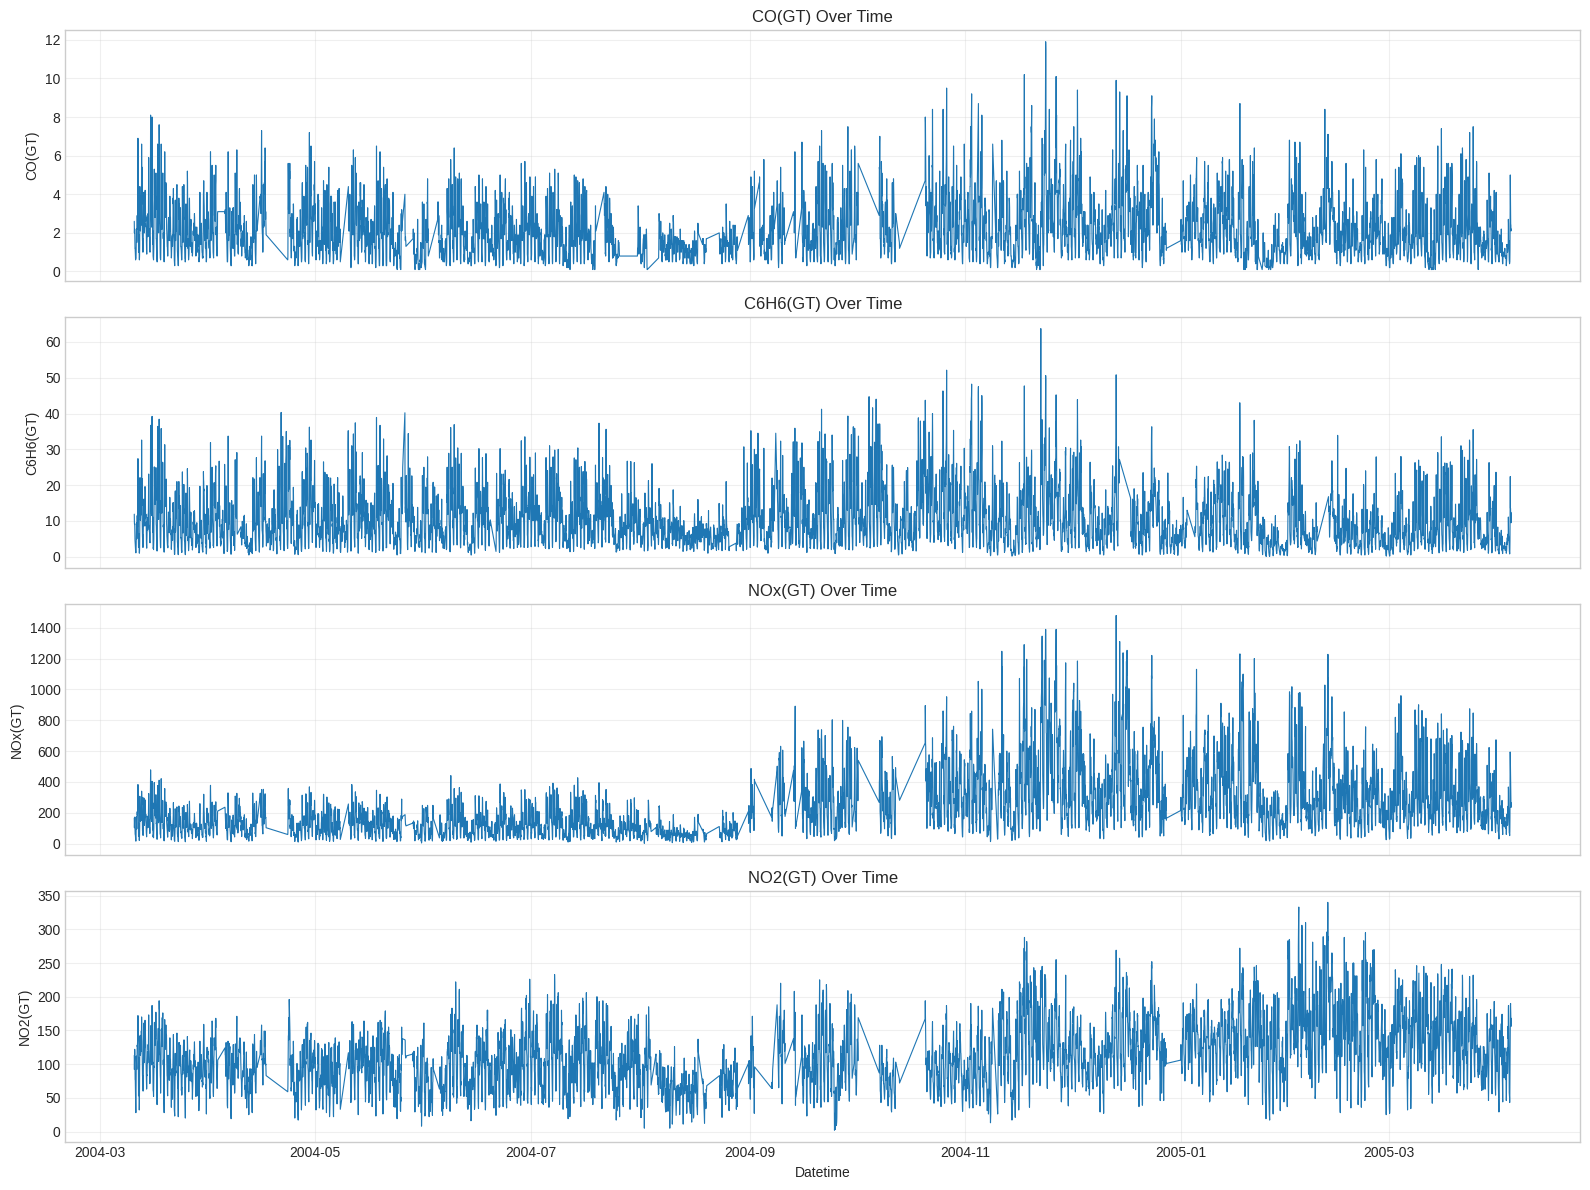

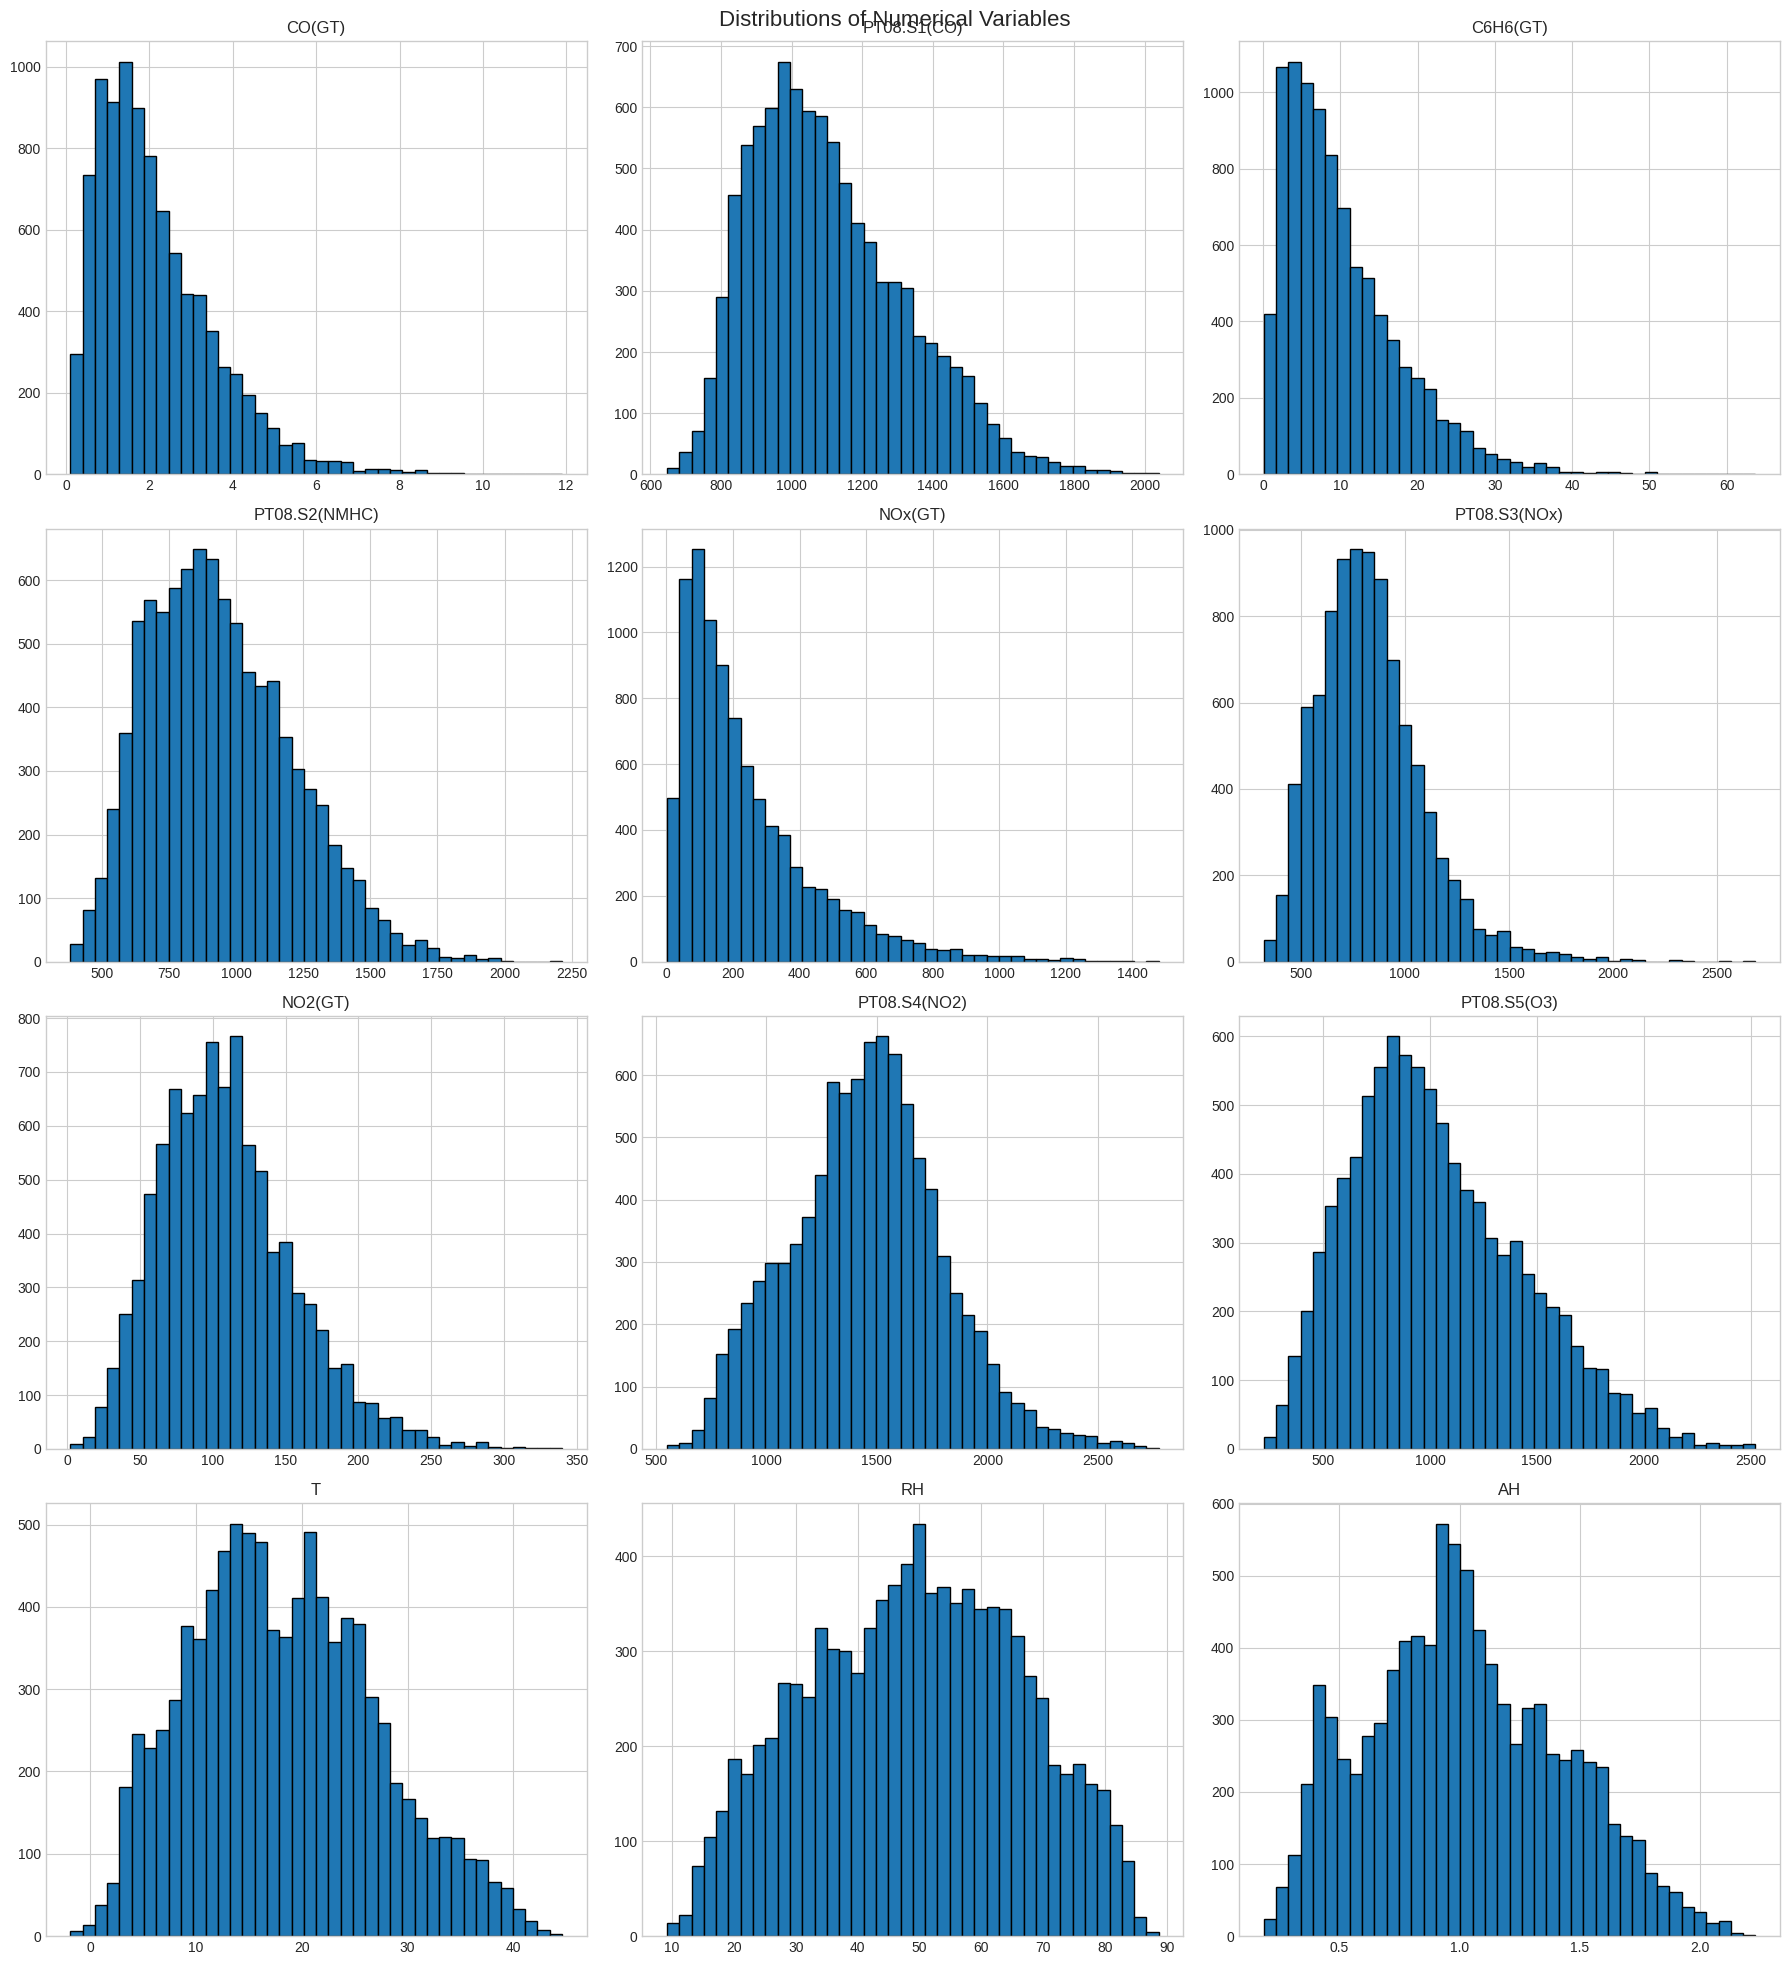

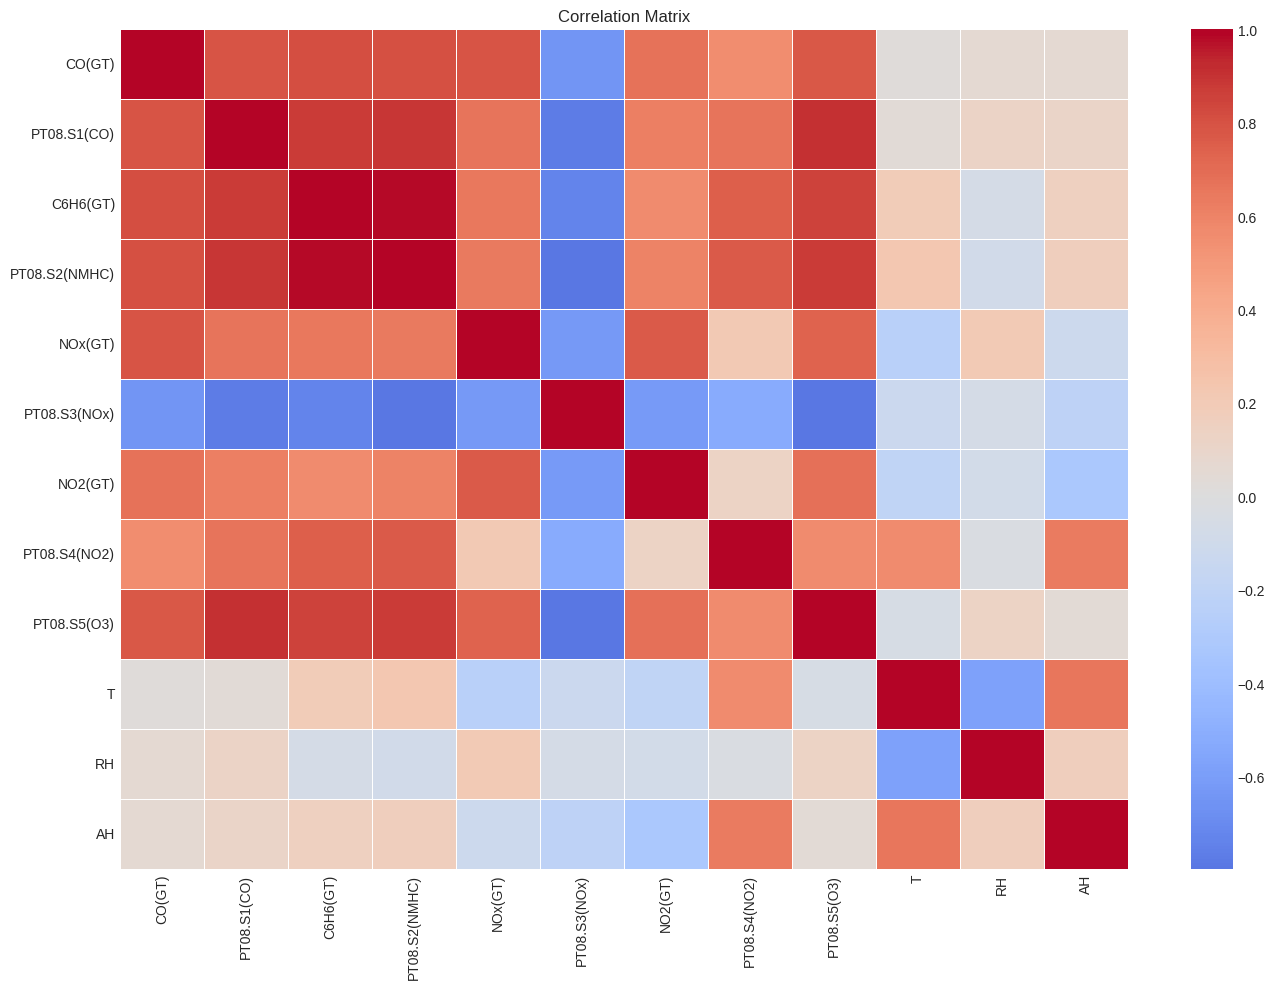

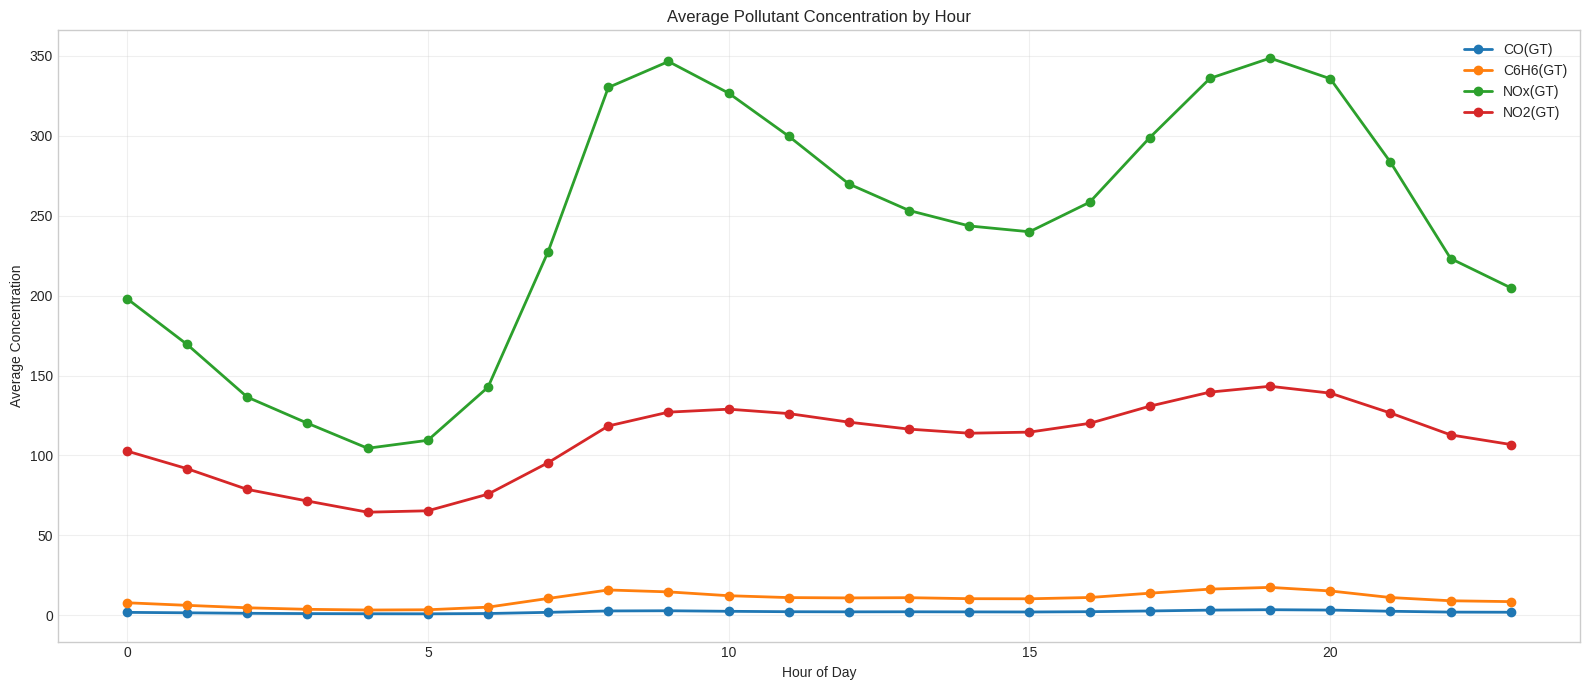

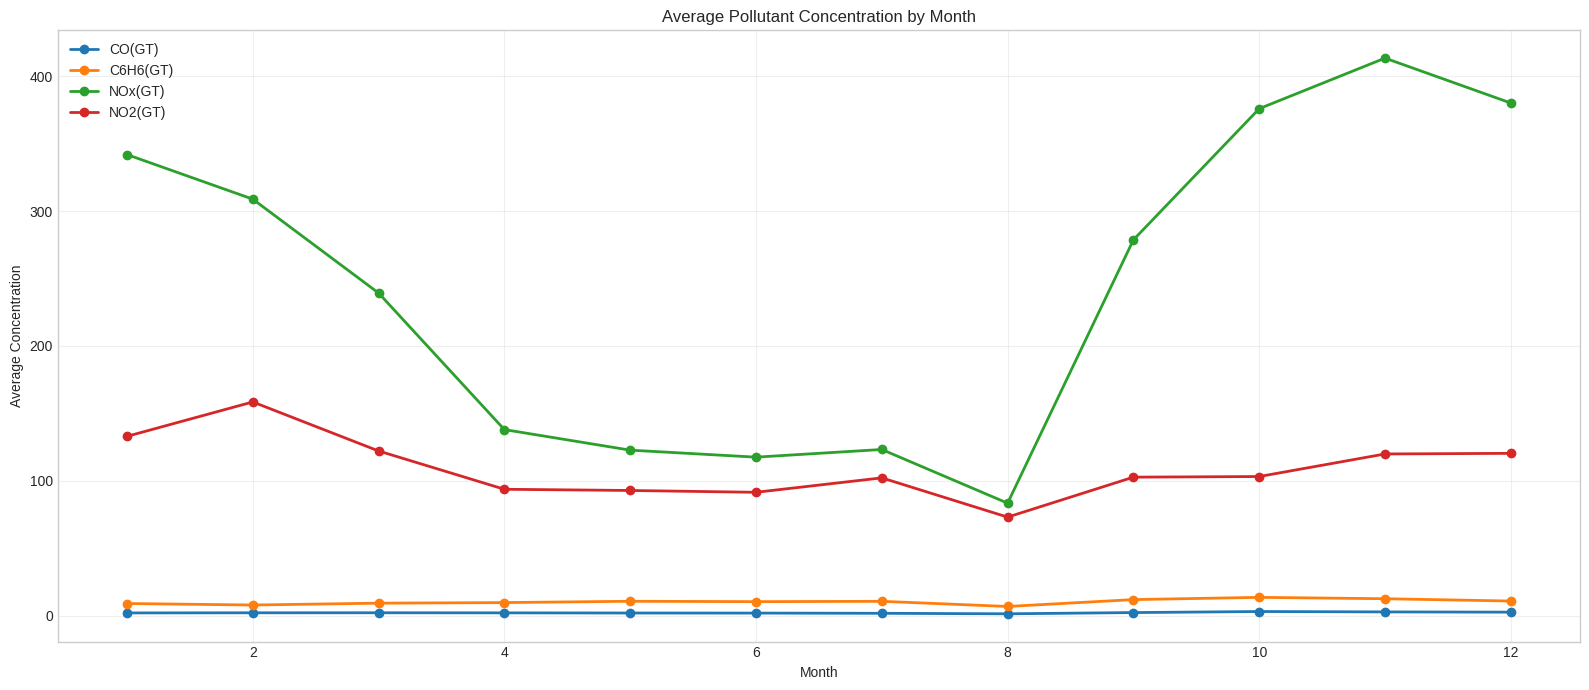


Exploratory analysis completed successfully.


In [7]:
# ==============================================================================
# PART B: EXPLORATORY DATA ANALYSIS
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("--- PART B: Exploratory Data Analysis ---")

# Display basic information
print("\nDataset Information:")
print(df.info())

print("\nDescriptive Statistics:")
display(df.describe().T)

# Check duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicate_count}")

# Remove duplicate rows, if any
df = df.drop_duplicates().reset_index(drop=True)

# Set Datetime as the index for time-series analysis
df = df.set_index('Datetime').sort_index()

# ---------------------------------------------------------------------
# 1. Plot selected pollutant concentrations over time
# ---------------------------------------------------------------------
pollutants = [
    col for col in ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
    if col in df.columns
]

fig, axes = plt.subplots(
    nrows=len(pollutants),
    ncols=1,
    figsize=(16, 3 * len(pollutants)),
    sharex=True
)

if len(pollutants) == 1:
    axes = [axes]

for ax, column in zip(axes, pollutants):
    ax.plot(df.index, df[column], linewidth=0.8)
    ax.set_title(f'{column} Over Time')
    ax.set_ylabel(column)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Datetime')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 2. Distribution of numerical variables
# ---------------------------------------------------------------------
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(
    bins=40,
    figsize=(18, 20),
    edgecolor='black'
)

plt.suptitle('Distributions of Numerical Variables', fontsize=16)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 3. Correlation matrix
# ---------------------------------------------------------------------
plt.figure(figsize=(14, 10))

correlation_matrix = df[numeric_cols].corr()

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0,
    annot=False,
    linewidths=0.5
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 4. Hourly pollutant patterns
# ---------------------------------------------------------------------
df['Hour'] = df.index.hour

hourly_means = df.groupby('Hour')[pollutants].mean()

hourly_means.plot(
    figsize=(16, 7),
    marker='o',
    linewidth=2
)

plt.title('Average Pollutant Concentration by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Concentration')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 5. Monthly pollutant patterns
# ---------------------------------------------------------------------
df['Month'] = df.index.month

monthly_means = df.groupby('Month')[pollutants].mean()

monthly_means.plot(
    figsize=(16, 7),
    marker='o',
    linewidth=2
)

plt.title('Average Pollutant Concentration by Month')
plt.xlabel('Month')
plt.ylabel('Average Concentration')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Remove helper columns if they are not needed later
df = df.drop(columns=['Hour', 'Month'])

print("\nExploratory analysis completed successfully.")


In [8]:
# ==============================================================================
# PART C: FEATURE ENGINEERING & TIME-SERIES PREPARATION
# ==============================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("--- PART C: Feature Engineering & Data Preparation ---")

# ---------------------------------------------------------------------
# 1. Select the target variable
# ---------------------------------------------------------------------
target = 'CO(GT)'

if target not in df.columns:
    raise ValueError(f"Target column '{target}' was not found in the dataset.")

# Work on a copy to preserve the original cleaned dataset
model_df = df.copy()

# ---------------------------------------------------------------------
# 2. Create time-based features
# ---------------------------------------------------------------------
model_df['Hour'] = model_df.index.hour
model_df['DayOfWeek'] = model_df.index.dayofweek
model_df['DayOfMonth'] = model_df.index.day
model_df['Month'] = model_df.index.month

# Cyclical encoding for hour and month
model_df['Hour_sin'] = np.sin(2 * np.pi * model_df['Hour'] / 24)
model_df['Hour_cos'] = np.cos(2 * np.pi * model_df['Hour'] / 24)

model_df['Month_sin'] = np.sin(2 * np.pi * model_df['Month'] / 12)
model_df['Month_cos'] = np.cos(2 * np.pi * model_df['Month'] / 12)

# ---------------------------------------------------------------------
# 3. Create lag features for the target
# ---------------------------------------------------------------------
lag_periods = [1, 2, 3, 6, 12, 24]

for lag in lag_periods:
    model_df[f'{target}_lag_{lag}'] = model_df[target].shift(lag)

# Rolling statistics based only on previous observations
model_df[f'{target}_rolling_mean_6'] = (
    model_df[target].shift(1).rolling(window=6).mean()
)

model_df[f'{target}_rolling_std_6'] = (
    model_df[target].shift(1).rolling(window=6).std()
)

model_df[f'{target}_rolling_mean_24'] = (
    model_df[target].shift(1).rolling(window=24).mean()
)

# ---------------------------------------------------------------------
# 4. Select useful predictor columns
# ---------------------------------------------------------------------
weather_features = [
    'T',        # Temperature
    'RH',       # Relative humidity
    'AH',        # Absolute humidity
]

pollutant_features = [
    'PT08.S1(CO)',
    'C6H6(GT)',
    'PT08.S2(NMHC)',
    'NOx(GT)',
    'PT08.S3(NOx)',
    'NO2(GT)',
    'PT08.S4(NO2)',
    'PT08.S5(O3)'
]

time_features = [
    'Hour_sin',
    'Hour_cos',
    'Month_sin',
    'Month_cos',
    'DayOfWeek'
]

lag_features = [
    f'{target}_lag_{lag}' for lag in lag_periods
] + [
    f'{target}_rolling_mean_6',
    f'{target}_rolling_std_6',
    f'{target}_rolling_mean_24'
]

# Keep only columns that actually exist
feature_columns = [
    col for col in (
        weather_features +
        pollutant_features +
        time_features +
        lag_features
    )
    if col in model_df.columns
]

print(f"Number of selected features: {len(feature_columns)}")
print("Selected features:")
print(feature_columns)

# ---------------------------------------------------------------------
# 5. Remove rows created invalid by lag/rolling operations
# ---------------------------------------------------------------------
required_columns = feature_columns + [target]

model_df = model_df[required_columns].replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

print(f"\nModeling dataset shape: {model_df.shape}")
print(f"Remaining missing values: {model_df.isnull().sum().sum()}")

# ---------------------------------------------------------------------
# 6. Prepare X and y
# ---------------------------------------------------------------------
X = model_df[feature_columns]
y = model_df[target]

# ---------------------------------------------------------------------
# 7. Chronological train-test split
# ----------------------------------------------


--- PART C: Feature Engineering & Data Preparation ---
Number of selected features: 25
Selected features:
['T', 'RH', 'AH', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'DayOfWeek', 'CO(GT)_lag_1', 'CO(GT)_lag_2', 'CO(GT)_lag_3', 'CO(GT)_lag_6', 'CO(GT)_lag_12', 'CO(GT)_lag_24', 'CO(GT)_rolling_mean_6', 'CO(GT)_rolling_std_6', 'CO(GT)_rolling_mean_24']

Modeling dataset shape: (9333, 26)
Remaining missing values: 0


In [9]:
# ==============================================================================
# PART D: CHRONOLOGICAL TRAIN-TEST SPLIT
# ==============================================================================

print("\n--- PART D: Chronological Train-Test Split ---")

# Use 80% data for training and 20% for testing
split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

print("\nTrain period:")
print(model_df.index[:split_index][0], "to", model_df.index[:split_index][-1])

print("\nTest period:")
print(model_df.index[split_index], "to", model_df.index[-1])


--- PART D: Chronological Train-Test Split ---
Training data shape: (7466, 25)
Testing data shape: (1867, 25)

Training target shape: (7466,)
Testing target shape: (1867,)

Train period:
2004-03-11 18:00:00 to 2005-01-16 19:00:00

Test period:
2005-01-16 20:00:00 to 2005-04-04 14:00:00


In [10]:
# ==============================================================================
# PART E: FEATURE SCALING
# ==============================================================================

print("\n--- PART E: Feature Scaling ---")

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

print("\nFeature scaling completed successfully.")


--- PART E: Feature Scaling ---
X_train_scaled shape: (7466, 25)
X_test_scaled shape: (1867, 25)

Feature scaling completed successfully.


In [11]:
# ==============================================================================
# PART F: LINEAR REGRESSION MODEL & EVALUATION
# ==============================================================================

from sklearn.linear_model import LinearRegression

print("\n--- PART F: Linear Regression Model ---")

# Create model
model = LinearRegression()

# Train model
model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("\n--- Training Performance ---")
print(f"MAE  : {train_mae:.4f}")
print(f"MSE  : {train_mse:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"R²   : {train_r2:.4f}")

print("\n--- Testing Performance ---")
print(f"MAE  : {test_mae:.4f}")
print(f"MSE  : {test_mse:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")


--- PART F: Linear Regression Model ---

--- Training Performance ---
MAE  : 0.2964
MSE  : 0.1777
RMSE : 0.4216
R²   : 0.9142

--- Testing Performance ---
MAE  : 0.2958
MSE  : 0.1906
RMSE : 0.4366
R²   : 0.9002


--- PART G: Actual vs Predicted CO ---


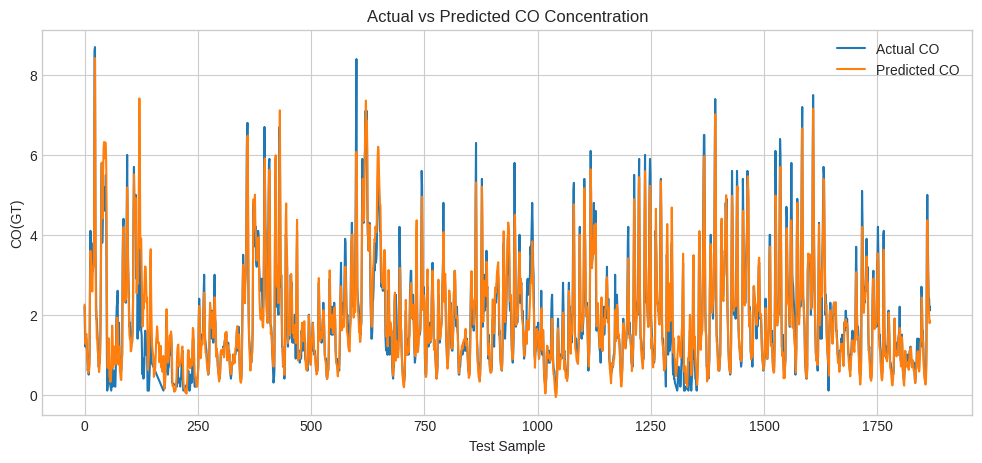

In [12]:
# ==============================================================================
# PART G: ACTUAL VS PREDICTED VALUES
# ==============================================================================

import matplotlib.pyplot as plt

print("--- PART G: Actual vs Predicted CO ---")

plt.figure(figsize=(12, 5))

plt.plot(y_test.values, label='Actual CO')
plt.plot(y_test_pred, label='Predicted CO')

plt.xlabel('Test Sample')
plt.ylabel('CO(GT)')
plt.title('Actual vs Predicted CO Concentration')
plt.legend()
plt.show()

--- PART H: Actual vs Predicted Scatter Plot ---


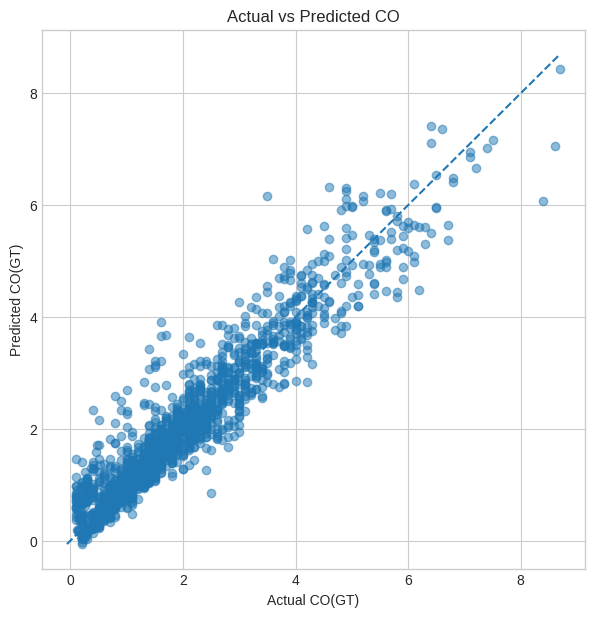

In [13]:
# ==============================================================================
# PART H: ACTUAL VS PREDICTED SCATTER PLOT
# ==============================================================================

print("--- PART H: Actual vs Predicted Scatter Plot ---")

plt.figure(figsize=(7, 7))

plt.scatter(y_test, y_test_pred, alpha=0.5)

# Perfect prediction line
min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual CO(GT)')
plt.ylabel('Predicted CO(GT)')
plt.title('Actual vs Predicted CO')

plt.show()

--- PART I: Residual Analysis ---
Residual statistics:
count    1867.000000
mean       -0.045781
std         0.434344
min        -2.663946
25%        -0.222778
50%         0.000457
75%         0.168898
max         2.322374
Name: CO(GT), dtype: float64


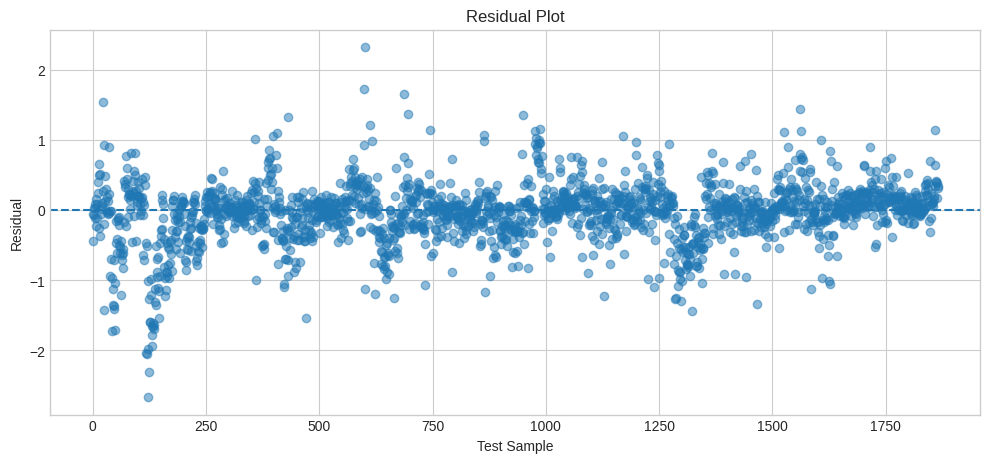

In [14]:
# ==============================================================================
# PART I: RESIDUAL ANALYSIS
# ==============================================================================

print("--- PART I: Residual Analysis ---")

# Calculate residuals
residuals = y_test - y_test_pred

print("Residual statistics:")
print(residuals.describe())

# Plot residuals
plt.figure(figsize=(12, 5))

plt.scatter(range(len(residuals)), residuals, alpha=0.5)

# Zero-error reference line
plt.axhline(y=0, linestyle='--')

plt.xlabel('Test Sample')
plt.ylabel('Residual')
plt.title('Residual Plot')

plt.show()

--- PART J: Feature Coefficients ---

Feature coefficients:


,Feature,Coefficient,Absolute_Coefficient
16,CO(GT)_lag_1,0.728829,0.728829
5,PT08.S2(NMHC),-0.612688,0.612688
9,PT08.S4(NO2),0.579166,0.579166
4,C6H6(GT),0.466995,0.466995
6,NOx(GT),0.444859,0.444859
10,PT08.S5(O3),-0.242354,0.242354
17,CO(GT)_lag_2,-0.233065,0.233065
3,PT08.S1(CO),0.212770,0.212770
8,NO2(GT),0.176730,0.176730
22,CO(GT)_rolling_mean_6,0.160076,0.160076


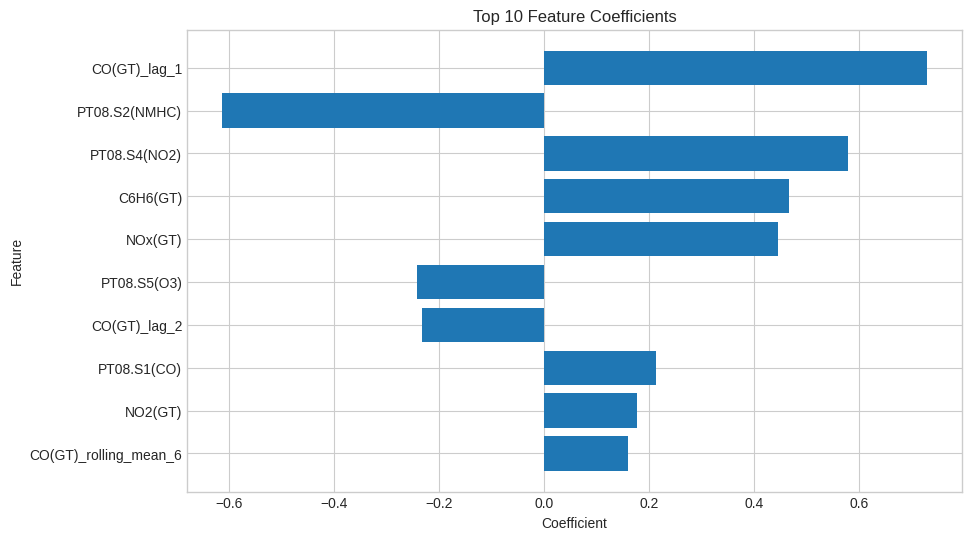

In [15]:
# ==============================================================================
# PART J: FEATURE COEFFICIENT ANALYSIS
# ==============================================================================

print("--- PART J: Feature Coefficients ---")

# Create a table of features and their coefficients
coefficient_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': model.coef_
})

# Sort by absolute coefficient value
coefficient_df['Absolute_Coefficient'] = (
    coefficient_df['Coefficient'].abs()
)

coefficient_df = coefficient_df.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

print("\nFeature coefficients:")
display(coefficient_df)

# Plot top features
plt.figure(figsize=(10, 6))

top_features = coefficient_df.head(10)

plt.barh(
    top_features['Feature'],
    top_features['Coefficient']
)

plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title('Top 10 Feature Coefficients')
plt.gca().invert_yaxis()

plt.show()

In [18]:
# ==============================================================================
# PART K: MODEL ANALYSIS & INSIGHTS
# ==============================================================================

print("=" * 70)
print("PART K: MODEL ANALYSIS & INSIGHTS")
print("=" * 70)

# ---------------------------------------------------------------------
# 1. Model performance summary
# ---------------------------------------------------------------------

print("\n1. MODEL PERFORMANCE")
print("-" * 40)

print(f"Test MAE  : {test_mae:.4f}")
print(f"Test MSE  : {test_mse:.4f}")
print(f"Test RMSE : {test_rmse:.4f}")
print(f"Test R²   : {test_r2:.4f}")

# ---------------------------------------------------------------------
# 2. Find observations with largest prediction errors
# ---------------------------------------------------------------------

results_df = pd.DataFrame({
    'Actual_CO': y_test.values,
    'Predicted_CO': y_test_pred,
})

results_df['Error'] = (
    results_df['Actual_CO'] - results_df['Predicted_CO']
)

results_df['Absolute_Error'] = results_df['Error'].abs()

print("\n2. LARGEST PREDICTION ERRORS")
print("-" * 40)

print(
    results_df
    .sort_values('Absolute_Error', ascending=False)
    .head(10)
)

# ---------------------------------------------------------------------
# 3. Most important features based on absolute coefficients
# ---------------------------------------------------------------------

print("\n3. MOST IMPORTANT FEATURES")
print("-" * 40)

importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': model.coef_,
})

importance_df['Absolute_Coefficient'] = (
    importance_df['Coefficient'].abs()
)

importance_df = importance_df.sort_values(
    'Absolute_Coefficient',
    ascending=False
)

print(importance_df.head(10).to_string(index=False))

# ---------------------------------------------------------------------
# 4. Key findings
# ---------------------------------------------------------------------

print("\n4. KEY FINDINGS")
print("-" * 40)

findings = [
    "Historical CO measurements provide useful information for predicting future CO concentration.",
    "Lag features help the model use recent air-quality information.",
    "Rolling statistics capture recent CO levels and their variability.",
    "Time-based features help capture daily and seasonal patterns.",
    "Weather and pollutant measurements provide additional information for CO prediction.",
    "Residual analysis helps identify observations with larger prediction errors.",
    "Chronological train-test splitting is appropriate for time-series prediction."
]

for i, finding in enumerate(findings, 1):
    print(f"{i}. {finding}")

# ---------------------------------------------------------------------
# 5. Limitations
# ---------------------------------------------------------------------

print("\n5. LIMITATIONS")
print("-" * 40)

limitations = [
    "Linear Regression assumes a linear relationship between features and CO concentration.",
    "The model may not capture sudden pollution events or unusual environmental conditions.",
    "The model is based on historical data and may not generalize perfectly to other locations."
]

for i, limitation in enumerate(limitations, 1):
    print(f"{i}. {limitation}")

# ---------------------------------------------------------------------
# 6. Future improvement
# ---------------------------------------------------------------------

print("\n6. FUTURE IMPROVEMENT")
print("-" * 40)

print(
    "Future work could compare Linear Regression with Random Forest, "
    "Gradient Boosting, XGBoost, or LSTM models. Time-series cross-validation "
    "and hyperparameter tuning could also be used to improve performance."
)

# ---------------------------------------------------------------------
# 7. Data leakage explanation
# ---------------------------------------------------------------------

print("\n7. DATA LEAKAGE PREVENTION")
print("-" * 40)

print(
    "Data leakage was avoided by using chronological train-test splitting. "
    "Lag and rolling features were created using previous observations with "
    "shift(1), preventing the current target value from being used as a feature. "
    "The StandardScaler was fitted only on the training data and then applied "
    "to the test data."
)

print("\n" + "=" * 70)
print("PART K COMPLETED SUCCESSFULLY")
print("=" * 70)

PART K: MODEL ANALYSIS & INSIGHTS

1. MODEL PERFORMANCE
----------------------------------------
Test MAE  : 0.2958
Test MSE  : 0.1906
Test RMSE : 0.4366
Test R²   : 0.9002

2. LARGEST PREDICTION ERRORS
----------------------------------------
     Actual_CO  Predicted_CO     Error  Absolute_Error
122        3.5      6.163946 -2.663946        2.663946
600        8.4      6.077626  2.322374        2.322374
125        1.6      3.908413 -2.308413        2.308413
119        1.6      3.653588 -2.053588        2.053588
117        1.4      3.435016 -2.035016        2.035016
123        1.7      3.673861 -1.973861        1.973861
130        0.4      2.338382 -1.938382        1.938382
132        0.8      2.584590 -1.784590        1.784590
43         4.6      6.321980 -1.721980        1.721980
599        6.2      4.481662  1.718338        1.718338

3. MOST IMPORTANT FEATURES
----------------------------------------
              Feature  Coefficient  Absolute_Coefficient
         CO(GT)_lag_1    

:::